# VE-SDE NCSN++ on CIFAR-10 Birds with Augmentation

Train and evaluate a VE-SDE score model with NCSN++ on augmented CIFAR-10 bird images.


In [ ]:
RUN_TRAINING = True
RUN_EVALUATION_AFTER_TRAINING = True

LOAD_FROM_CHECKPOINT = True
CHECKPOINT_TO_LOAD = "/content/drive/MyDrive/DD2424/Project/working_nets/bird_ve_sde_augmented_ncsnpp_1000_epochs.pth"

SAVE_CHECKPOINTS = True

target_class_name = "bird"
batch_size=128

# Training
epochs=1760
learning_rate = 1e-4
weight_decay=1e-4
ema_decay=0.995

# VE-SDE sigma schedule
bar_sigma_min = 0.01
bar_sigma_max = 50.0

# Sampling
sample_num_steps = 1000
sample_eps = 1e-3
sample_snr = 0.01
sample_corrector_steps = 0

# Evaluation
fid_num_generated = 1000
fid_gen_batch_size = 64
mem_num_generated = 64
mem_reference_images = 10 #5000

# Paths
path = "/content/drive/MyDrive/DD2424/Project/working_nets"


## Imports


In [ ]:
import os
import sys
import math
import time
import copy
import subprocess
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Subset, DataLoader
from torchvision.utils import make_grid
from tqdm import tqdm


device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Google Drive


In [ ]:
from google.colab import drive

drive.mount("/content/drive")
os.makedirs(path, exist_ok=True)
project_root = os.path.dirname(path) if os.path.basename(path) == "working_nets" else path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if path not in sys.path:
    sys.path.insert(0, path)

print("Project path:", path)
print("Files in project path:", os.listdir(path))


Mounted at /content/drive
Project path: /content/drive/MyDrive/DD2424/Project/working_nets
Files in project path: ['score_sde_pytorch', 'Untitled0.ipynb', 'VE_sde_cifar10_ncsnpp.ipynb', 'bird_vp_sde_augmented_final_ddpmpp_1760_epochs.pth', 'ema_generated_samples_grid.png', 'vp_generated_samples_grid.png', 'comparison_raw_vp_net_grid.png', 'comparison_ema_net_grid.png', 'vp_net1600_epochs_generated_grid.png', 'vp_net1600_epochs_evaluation_results.txt', 'EMA_net1600_epochs_generated_grid.png', 'EMA_net1600_epochs_evaluation_results.txt', 'vp_sde_augmented_ddpmpp_net.ipynb', 'ema_generated_samples_grid_ve.png', 've_generated_samples_grid_ve.png', 'bird_ve_sde_augmented_ncsnpp_500_epochs.pth', 'bird_ve_sde_augmented_ncsnpp_1000_epochs.pth', 've_sde_augmented_ddpmpp_net.ipynb']


In [ ]:
from src.plotting import denormalize, imshow, show_batch_from_loader, show_images, plot_loss, save_tensor_images_as_grid
from src.configs import create_ncsnpp_ve_config
from src.sde import update_ema


## Load CIFAR-10 Data


In [ ]:
# Plain transform: used for visualization, FID real images, and memorization check
transform_plain = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Augmented transform: used for training
# Use reflection padding to avoid artificial black borders from RandomCrop.
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load full plain training set to find bird indices
trainset_plain_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_plain)

target_idx = trainset_plain_full.classes.index(target_class_name)

train_indices = [
    i for i, label in enumerate(trainset_plain_full.targets)
    if label == target_idx
]

# Plain bird training set
trainset_plain = Subset(trainset_plain_full, train_indices)

trainloader_plain = DataLoader(trainset_plain, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Augmented bird training set
trainset_aug_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)

trainset_aug = Subset(trainset_aug_full, train_indices)

trainloader_aug = DataLoader(trainset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# This is the training loader used by the model
trainloader = trainloader_aug

# Test set: plain transform, bird class only
testset_full = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_plain)

test_indices = [
    i for i, label in enumerate(testset_full.targets)
    if label == target_idx
]

testset = Subset(testset_full, test_indices)

testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Target class:", target_class_name)
print("Target class index:", target_idx)
print("Number of bird training images:", len(trainset_aug))
print("Number of bird test images:", len(testset))
print("Steps per epoch:", math.ceil(len(trainset_aug) / batch_size))


100%|██████████| 170M/170M [00:17<00:00, 9.72MB/s]


Target class: bird
Target class index: 2
Number of bird training images: 5000
Number of bird test images: 1000
Steps per epoch: 40


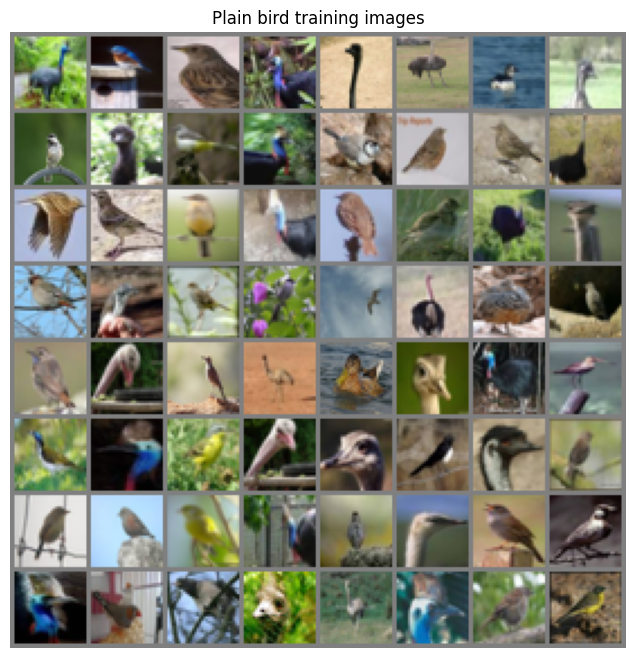

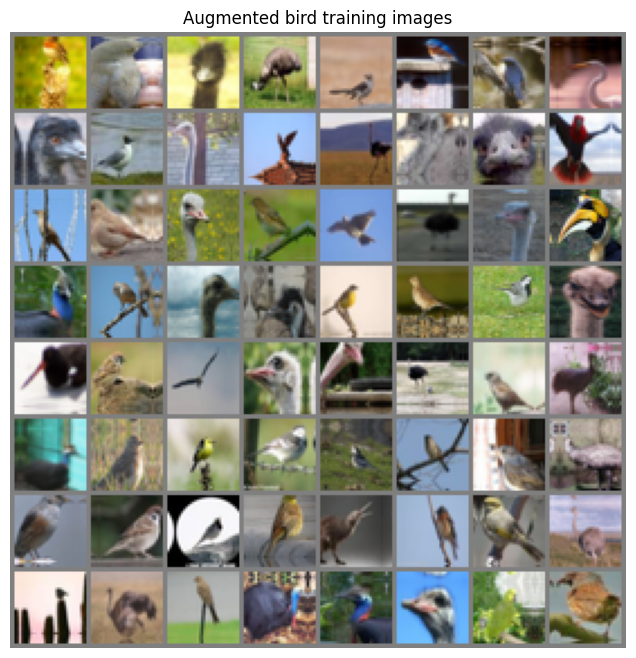

In [ ]:
show_batch_from_loader(trainloader_plain, title="Plain bird training images")
show_batch_from_loader(trainloader_aug, title="Augmented bird training images")


In [ ]:
!pip install ninja #need this library to import from github


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.6 MB/s eta 0:00:00


## Import Score Model Architecture


In [ ]:
from types import SimpleNamespace

score_sde_repository_path = os.path.join(path, "score_sde_pytorch")

if not os.path.exists(score_sde_repository_path):
    !git clone https://github.com/yang-song/score_sde_pytorch.git "{score_sde_repository_path}"

if score_sde_repository_path not in sys.path:
    sys.path.insert(0, score_sde_repository_path)

from models.ncsnpp import NCSNpp

print("imported NCSNpp architecture")


imported NCSNpp architecture


In [ ]:
class NCSNppVEScoreWrapper(nn.Module):
    def __init__(self, official_model, number_of_scales=1000):
        super().__init__()
        self.official_model = official_model
        self.number_of_scales = number_of_scales

        def forward(self, images, continuous_timesteps):
            timestep_labels = continuous_timesteps * (self.number_of_scales - 1)

            model_output = self.official_model(images, timestep_labels)

            _, standard_deviation = perturbation_kernel(continuous_timesteps, images)

            score = -model_output / standard_deviation

        return score


In [ ]:
ncsnpp_config = create_ncsnpp_ve_config(image_size=32, image_channels=3)

official_ncsnpp_model = NCSNpp(ncsnpp_config).to(device)

ve_net = NCSNppVEScoreWrapper(official_model=official_ncsnpp_model).to(device)

number_of_parameters = sum(parameter.numel() for parameter in ve_net.parameters())
print("ncsn+ style model params", number_of_parameters)


ncsn+ style model params 62758915


## SDE Objective


In [ ]:
def sigma_t(t, sigma_min=0.01, sigma_max=50.0):
    return sigma_min * (sigma_max / sigma_min) ** t


def perturbation_kernel(t, x0, sigma_min=0.01, sigma_max=50):
    mean = x0
    std = sigma_t(t, sigma_min, sigma_max).view(-1, 1, 1, 1)
    return mean, std


def cont_loss(x0, net):
    B = x0.shape[0]

    eps=1e-5
    t = torch.rand(B, device=x0.device) * (1.0 - eps) + eps
    z = torch.randn_like(x0)

    mean, std = perturbation_kernel(t, x0)
    x_t = mean + std * z

    score_pred = net(x_t, t)

    loss = ((score_pred * std + z) ** 2).mean()

    return loss


In [ ]:
if LOAD_FROM_CHECKPOINT:
    print("Loading checkpoint:", CHECKPOINT_TO_LOAD)

    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=device)


    #NCSNPP network
    ve_net = NCSNppVEScoreWrapper(official_model=official_ncsnpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

    number_of_parameters = sum(parameter.numel() for parameter in ve_net.parameters())

    #NCSNPP network
    ema_net = copy.deepcopy(ve_net).to(device)
    ema_net.eval()


    ve_net.load_state_dict(checkpoint["ve_net"])
    ema_net.load_state_dict(checkpoint["ema_net"])

    learning_rate = checkpoint.get("learning_rate", learning_rate)
    weight_decay=checkpoint.get("weight_decay", weight_decay)
    ema_decay=checkpoint.get("ema_decay", ema_decay)
    loss_hist = checkpoint.get("loss_hist", [])
    start_epoch=checkpoint.get("epochs", 0)

    print(start_epoch)

    optimizer = optim.AdamW(ve_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    optimizer.load_state_dict(checkpoint["optimizer"])

    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(device)

                ve_net.train()
                ema_net.eval()

            for p in ema_net.parameters():
                p.requires_grad_(False)

                print("Loaded checkpoint.")
                print("Start epoch:", start_epoch)
                print("Loaded loss history length:", len(loss_hist))

else:
    print("Initializing new model.")

    #NCSNPM network
    ve_net = NCSNppVEScoreWrapper(official_model=official_ncsnpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

    number_of_parameters = sum(parameter.numel() for parameter in ve_net.parameters())

    #NCSNPP network
    ema_net = copy.deepcopy(ve_net).to(device)
    ema_net.eval()


    for p in ema_net.parameters():
        p.requires_grad_(False)

        optimizer = optim.AdamW(ve_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

        loss_hist = []
        start_epoch=0

        print("New model initialized.")


Loading checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ve_sde_augmented_ncsnpp_1000_epochs.pth
1000
Loaded checkpoint.
Start epoch: 1000
Loaded loss history length: 40000


## Configuration


In [ ]:
def train_ve_sde(ve_net, ema_net, optimizer, trainloader, start_epoch=0, epochs=1760, ema_decay=0.995, checkpoint_every=500, checkpoint_prefix="bird_ve_sde_augmented_ncsnpp"):
    global loss_hist
    end_epoch = epochs
    print("end epoch:", end_epoch)
    print("start epoch:", start_epoch)

    for epoch in tqdm(range(start_epoch, end_epoch)):
        ve_net.train()
        ema_net.eval()
        epoch_losses = []

        for i, (images, _) in enumerate(trainloader):
            images = images.to(device)
            loss = cont_loss(images, ve_net)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ve_net.parameters(), max_norm=1.0)
            optimizer.step()
            update_ema(ema_net, ve_net, decay=ema_decay)

            loss_hist.append(loss.item())
            epoch_losses.append(loss.item())

        if epoch % 10 == 0:
            print(f"VE epoch {epoch} | Mean loss {np.mean(epoch_losses):.4f}")

        if SAVE_CHECKPOINTS and checkpoint_every is not None and (epoch + 1) % checkpoint_every == 0:
            checkpoint_path = os.path.join(path, f"{checkpoint_prefix}_{epoch + 1}_epochs.pth")
            checkpoint = {"ve_net": ve_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
            checkpoint["epochs"] = epoch + 1
            checkpoint["batch_size"] = batch_size
            checkpoint["learning_rate"] = learning_rate
            checkpoint["weight_decay"] = weight_decay
            checkpoint["ema_decay"] = ema_decay
            checkpoint["bar_sigma_min"] = bar_sigma_min
            checkpoint["bar_sigma_max"] = bar_sigma_max
            checkpoint["augmentation"] = True
            checkpoint["target_class_name"] = target_class_name
            torch.save(checkpoint, checkpoint_path)
            print("Saved checkpoint:", checkpoint_path)

    return end_epoch


if RUN_TRAINING:
    print("Training VE-SDE model...")
    final_epoch = train_ve_sde(ve_net, ema_net, optimizer, trainloader_aug, start_epoch=start_epoch, epochs=epochs, ema_decay=ema_decay, checkpoint_every=500, checkpoint_prefix="bird_ve_sde_augmented_ncsnpp")
    final_checkpoint_path = os.path.join(path, f"bird_ve_sde_augmented_final_ncsnpp_{final_epoch}_epochs.pth")
    checkpoint = {"ve_net": ve_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
    checkpoint["epochs"] = final_epoch
    checkpoint["batch_size"] = batch_size
    checkpoint["learning_rate"] = learning_rate
    checkpoint["weight_decay"] = weight_decay
    checkpoint["ema_decay"] = ema_decay
    checkpoint["bar_sigma_min"] = bar_sigma_min
    checkpoint["bar_sigma_max"] = bar_sigma_max
    checkpoint["augmentation"] = True
    checkpoint["target_class_name"] = target_class_name
    torch.save(checkpoint, final_checkpoint_path)
    print("Saved final checkpoint:", final_checkpoint_path)

else:
    final_epoch = start_epoch


Training VE-SDE model...
end epoch:  1760
start epoch:  1000


  0%|          | 0/760 [00:00<?, ?it/s]

epoch:  1000


  0%|          | 1/760 [00:10<2:12:01, 10.44s/it]

VE epoch 1000 | Mean loss 0.1792
epoch:  1001


...

epoch:  1758


100%|█████████▉| 759/760 [2:12:34<00:10, 10.39s/it]

epoch:  1759


100%|██████████| 760/760 [2:12:44<00:00, 10.48s/it]


Saved final checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ve_sde_augmented_final_ncsnpp_1760_epochs.pth


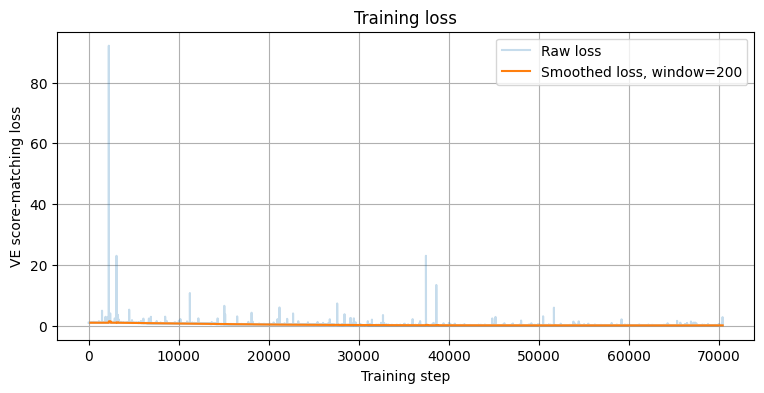

In [ ]:
plot_loss(loss_hist, smooth_window=200)


In [ ]:
@torch.no_grad()
def langevin_corrector_ve(x, t, net, snr=0.05, n_steps=1, eps=1e-12):
    batch_size_local = x.shape[0]
    batch_t = torch.ones(batch_size_local, device=x.device) * t

    for _ in range(n_steps):
        noise = torch.randn_like(x)
        score = net(x, batch_t)
        score_norm = torch.norm(score.reshape(batch_size_local, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(batch_size_local, -1), dim=1).mean()
        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


def g_squared_t(batch_t, sigma_min=0.01, sigma_max=50):
    sig_t = sigma_t(batch_t, sigma_min, sigma_max)
    return 2.0 * (sig_t ** 2) * math.log(sigma_max / sigma_min)


@torch.no_grad()
def euler_maruyama_predictor_ve(x, t, t_next, net, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=device) * t

    g_squared = g_squared_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = g_squared * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(g_squared * h) * noise
    else:
        x = x_mean

    return x, x_mean


## Sampling


In [ ]:
@torch.no_grad()
def sample_pc_ve_sde_continuous(net, num_samples=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.05, corrector_steps=0, denoise=True):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)
    x_mean = x

    for i in tqdm(range(num_steps - 1)):
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_ve(x, t, net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2
        x, x_mean = euler_maruyama_predictor_ve(x, t, t_next, net, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)


@torch.no_grad()
def sample_pc_ve_sde_continuous_evolution(net, num_pics=4, num_samples=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.05, corrector_steps=1, denoise=True, sigma_max=50.0):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device) * sigma_max
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)
    x_mean = x
    list_diff = []
    save_pic_it = max(1, num_steps // max(1, num_pics - 1))

    for i in tqdm.tqdm(range(num_steps - 1)):
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_ve(x, t, net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2
        x, x_mean = euler_maruyama_predictor_ve(x, t, t_next, net, add_noise=add_noise)

        if (i % save_pic_it) == 0:
            sample_to_save = x_mean if denoise else x
            list_diff.append(sample_to_save.clamp(-1, 1).cpu())
            sample_to_save = x_mean if denoise else x
            list_diff.append(sample_to_save.clamp(-1, 1).cpu())

    return torch.stack(list_diff, dim=0)


100%|██████████| 99/99 [00:07<00:00, 12.80it/s]


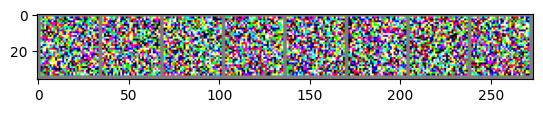

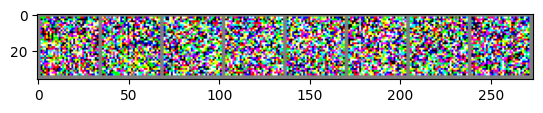

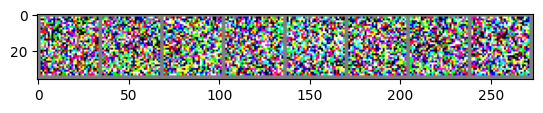

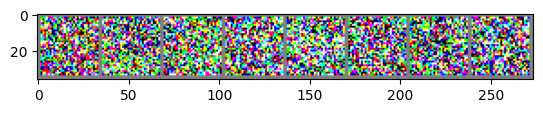

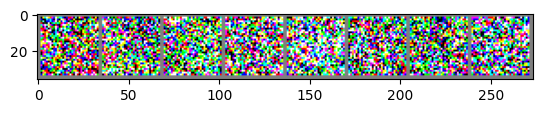

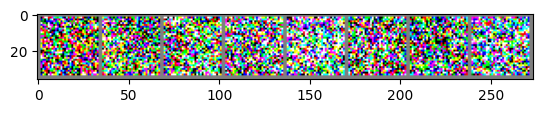

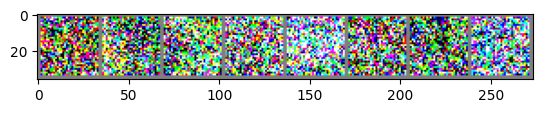

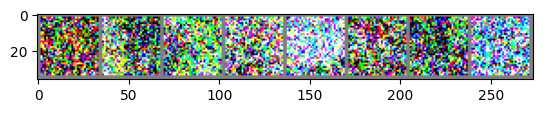

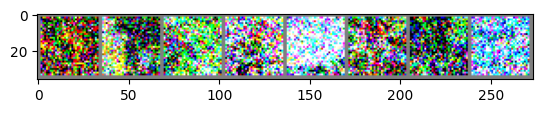

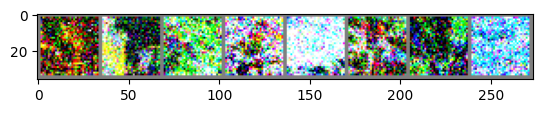

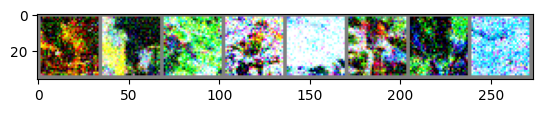

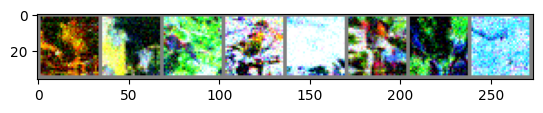

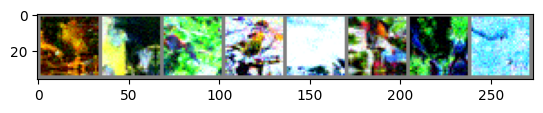

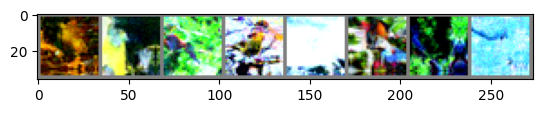

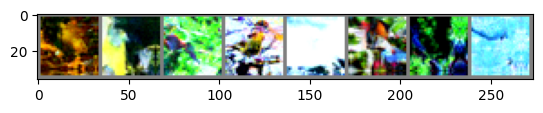

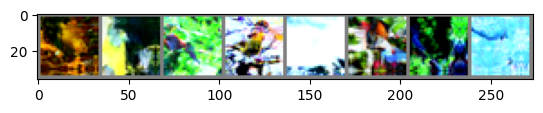

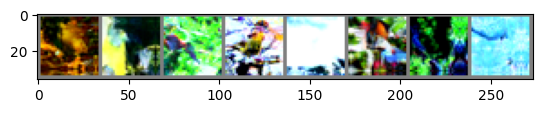

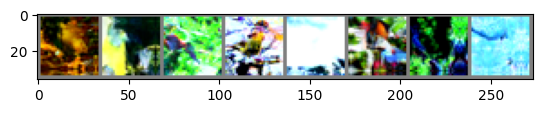

In [ ]:
import tqdm #was a bug, so i had to import this one

samples_pc = sample_pc_ve_sde_continuous_evolution(net=ema_net, num_pics=16, num_samples=8, img_shape=(3, 32, 32), num_steps=100, eps=0.001, snr=0.01, corrector_steps=1, denoise=True)

num_pics = samples_pc.shape[0]

for i in range(num_pics):
    grid = torchvision.utils.make_grid(samples_pc[i].detach().cpu(), nrow=8)
    imshow(grid)


In [ ]:
#jonathan ville att jag skulle köra detta

samples_pc = sample_pc_ve_sde_continuous(net=ema_net, num_pics=16, num_samples=8, img_shape=(3, 32, 32), num_steps=100, eps=0.001, snr=0.01, corrector_steps=1, denoise=True)

num_pics, num_samples=samples_pc.shape[:2]

samples_flat = samples_pc.detach().cpu().reshape(num_pics * num_samples, *samples_pc.shape[2:])
grid = torchvision.utils.make_grid(samples_flat, nrow=8, padding=2, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(16, 2 * num_pics))
plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
plt.axis("off")
plt.tight_layout()
plt.show()


TypeError: sample_pc_ve_sde_continuous() got an unexpected keyword argument 'num_pics'

100%|██████████| 999/999 [00:39<00:00, 25.25it/s]


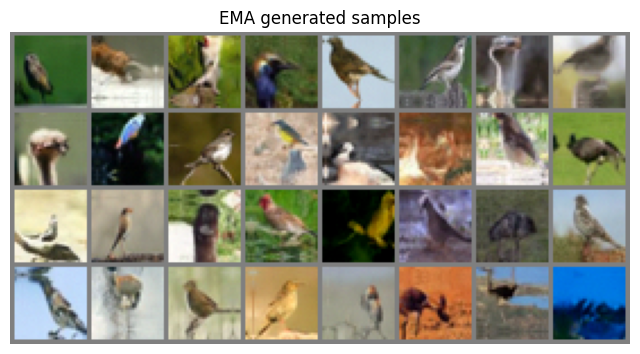

100%|██████████| 999/999 [00:39<00:00, 25.08it/s]


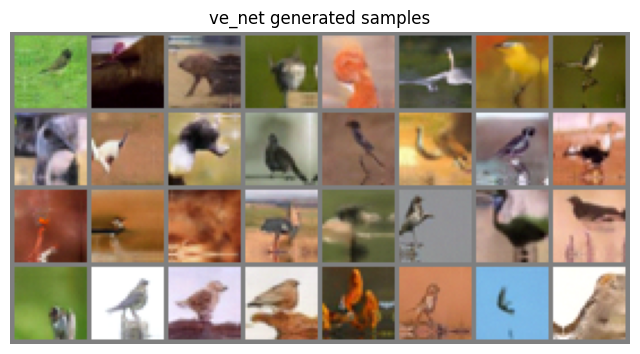

In [ ]:
samples_ema = sample_pc_ve_sde_continuous(ema_net, num_samples=32, img_shape=(3, 32, 32), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_ema, title="EMA generated samples", nrow=8)

samples_raw = sample_pc_ve_sde_continuous(ve_net, num_samples=32, img_shape=(3, 32, 32), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_raw, title="ve_net generated samples", nrow=8)


In [ ]:
samples_ema.shape


torch.Size([32, 3, 32, 32])

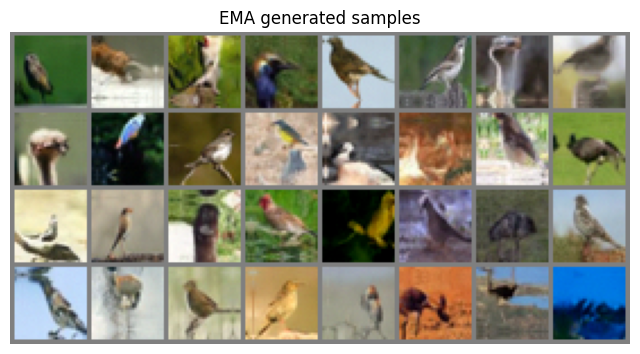

In [ ]:
show_images(samples_ema, title="EMA generated samples", nrow=8)


In [ ]:
save_tensor_images_as_grid(samples_ema, os.path.join(path, 'ema_generated_samples_grid_ve.png'), nrow=8)

save_tensor_images_as_grid(samples_raw, os.path.join(path, 've_generated_samples_grid_ve.png'), nrow=8)


Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/ema_generated_samples_grid_ve.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/ve_generated_samples_grid_ve.png


In [ ]:
@torch.no_grad()
def generate_samples_in_batches(model, total_samples=1000, sample_batch_size=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True):
    model.eval()
    all_samples = []
    generated = 0

    while generated < total_samples:
        current_batch = min(sample_batch_size, total_samples - generated)
        samples = sample_pc_ve_sde_continuous(model, num_samples=current_batch, img_shape=img_shape, num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise)
        all_samples.append(samples.detach().cpu())
        generated += current_batch
        print(f"Generated {generated}/{total_samples} samples")

    return torch.cat(all_samples, dim=0)


## FID Evaluation


In [ ]:
def to_uint8_images(x):
    x = denormalize(x)
    x = (x * 255.0).round().clamp(0, 255).to(torch.uint8)
    return x


def install_fid_dependencies_if_needed():
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance
    except Exception:
        print("Installing torchmetrics and torch-fidelity...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics", "torch-fidelity"])
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance


@torch.no_grad()
def compute_fid_for_model(model, real_loader, num_generated=1000, gen_batch_size=64, real_max_images=1000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, feature=2048):
    FrechetInceptionDistance = install_fid_dependencies_if_needed()
    fid = FrechetInceptionDistance(feature=feature, normalize=False).to(device)
    model.eval()

    real_count = 0
    for real_images, _ in real_loader:
        real_images = real_images.to(device)
        fid.update(to_uint8_images(real_images), real=True)
        real_count += real_images.shape[0]
        if real_count >= real_max_images:
            break

    print("Real images added to FID:", real_count)

    gen_count = 0
    while gen_count < num_generated:
        current_batch = min(gen_batch_size, num_generated - gen_count)
        samples = sample_pc_ve_sde_continuous(
            model, num_samples=current_batch, img_shape=(3, 32, 32),
            num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise
        )
        fid.update(to_uint8_images(samples), real=False)
        gen_count += current_batch
        print(f"Generated images added to FID: {gen_count}/{num_generated}")

    fid_value = fid.compute().item()
    print("FID:", fid_value)
    return fid_value


def fid_sampling_steps_experiment(model, real_loader, steps_list=(100, 250, 500, 1000), num_generated=1000, gen_batch_size=64, corrector_steps=0):
    results = {}

    for steps in steps_list:
        print("\n====================================")
        print("Computing FID with num_steps =", steps)
        print("====================================")
        start_time = time.time()
        fid_value = compute_fid_for_model(model, real_loader, num_generated=num_generated, gen_batch_size=gen_batch_size,
            real_max_images=1000, num_steps=steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True)
        elapsed = time.time() - start_time
        results[steps] = {"fid": fid_value, "time_seconds": elapsed}
        print(f"num_steps={steps} | FID={fid_value:.4f} | time={elapsed:.2f}s")

    return results


## Memorization Check


In [ ]:
@torch.no_grad()
def collect_images_from_loader(loader, max_images=5000):
    all_images = []
    count = 0

    for images, _ in loader:
        images = images.to(device)
        all_images.append(images)
        count += images.shape[0]
        if count >= max_images:
            break

    all_images = torch.cat(all_images, dim=0)
    return all_images[:max_images]


@torch.no_grad()
def nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512):
    generated_images = generated_images.to(device)
    reference_images = reference_images.to(device)
    N = generated_images.shape[0]
    M = reference_images.shape[0]
    gen_flat = generated_images.reshape(N, -1)
    best_distances = torch.full((N,), float("inf"), device=device)
    best_indices = torch.zeros((N,), dtype=torch.long, device=device)

    for start in range(0, M, ref_batch_size):
        end = min(start + ref_batch_size, M)
        ref_batch = reference_images[start:end]
        ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)
        dists = torch.cdist(gen_flat, ref_flat, p=2) ** 2 / gen_flat.shape[1]
        min_dists, min_idx = dists.min(dim=1)
        better = min_dists < best_distances
        best_distances[better] = min_dists[better]
        best_indices[better] = start + min_idx[better]

    return best_indices.detach().cpu(), best_distances.detach().cpu()


def show_generated_vs_nearest(generated_images, reference_images, nearest_indices, nearest_distances=None, num_show=8):
    generated_images = generated_images.detach().cpu()
    reference_images = reference_images.detach().cpu()
    num_show = min(num_show, generated_images.shape[0])

    pairs = []
    for i in range(num_show):
        pairs.append(generated_images[i])
        pairs.append(reference_images[nearest_indices[i]])

    grid = make_grid(torch.stack(pairs, dim=0), nrow=2)
    img = denormalize(grid).numpy()
    plt.figure(figsize=(6, 3 * num_show))
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.axis("off")

    if nearest_distances is not None:
        mean_dist = nearest_distances[:num_show].mean().item()
        plt.title(f"Generated vs nearest training image | mean MSE={mean_dist:.6f}")
    else:
        plt.title("Generated vs nearest training image")

    plt.show()


@torch.no_grad()
def memorization_check(model, trainloader_reference, num_generated=64, generation_batch_size=64, max_reference_images=5000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, show_num=8):
    print("Collecting reference training images...")
    reference_images = collect_images_from_loader(trainloader_reference, max_images=max_reference_images)
    print("Reference images:", reference_images.shape)

    print("Generating images for memorization check...")
    generated_images = generate_samples_in_batches(model, total_samples=num_generated, sample_batch_size=generation_batch_size,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise).to(device)
    print("Generated images:", generated_images.shape)

    print("Finding nearest training neighbors...")
    nearest_indices, nearest_distances = nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512)
    print("Mean nearest-neighbor MSE:", nearest_distances.mean().item())
    print("Median nearest-neighbor MSE:", nearest_distances.median().item())
    print("Minimum nearest-neighbor MSE:", nearest_distances.min().item())
    print("Maximum nearest-neighbor MSE:", nearest_distances.max().item())

    show_generated_vs_nearest(generated_images.cpu(), reference_images.cpu(), nearest_indices, nearest_distances, num_show=show_num)
    return {
        "generated_images": generated_images.detach().cpu(), "reference_images": reference_images.detach().cpu(),
        "nearest_indices": nearest_indices, "nearest_distances": nearest_distances
    }


def plot_nearest_neighbor_distance_histogram(mem_results, bins=30):
    distances = mem_results["nearest_distances"].numpy()
    plt.figure(figsize=(7, 4))
    plt.hist(distances, bins=bins)
    plt.xlabel("Nearest-neighbor pixel MSE")
    plt.ylabel("Number of generated samples")
    plt.title("Memorization check: nearest-neighbor distance distribution")
    plt.grid(True)
    plt.show()


def save_memorization_report(mem_results, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    distances = mem_results["nearest_distances"].numpy()

    with open(filename, "w") as f:
        f.write("Memorization nearest-neighbor report\n")
        f.write("====================================\n")
        f.write(f"Number of generated samples: {len(distances)}\n")
        f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")
        f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")
        f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")
        f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")

    print("Saved memorization report:", filename)


'\ndef save_memorization_report(mem_results, filename):\n    os.makedirs(os.path.dirname(filename), exist_ok=True)\n\n    distances = mem_results["nearest_distances"].numpy()\n\n    with open(filename, "w") as f:\n        f.write("Memorization nearest-neighbor report\n")\n        f.write("====================================\n")\n        f.write(f"Number of generated samples: {len(distances)}\n")\n        f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")\n        f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")\n        f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")\n        f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")\n        f.write("\n")\n        f.write("Interpretation:\n")\n        f.write(\n            "Very small nearest-neighbor distances may indicate memorization, "\n            "especially if generated images visually match training images. "\n            "Larger distances suggest that generated image

In [ ]:
def compare_raw_vs_ema(ve_net, ema_net, num_samples=64, num_steps=1000, corrector_steps=0):
    torch.manual_seed(0)
    samples_raw = generate_samples_in_batches(
        model=ve_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    torch.manual_seed(0)
    samples_ema = generate_samples_in_batches(
        model=ema_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    show_images(samples_raw[:64], title="Raw ve_net samples", nrow=8)
    show_images(samples_ema[:64], title="EMA ema_net samples", nrow=8)
    save_tensor_images_as_grid(samples_raw[:64], os.path.join(path, 'comparison_raw_ve_net_grid.png'), nrow=8)
    save_tensor_images_as_grid(samples_ema[:64], os.path.join(path, 'comparison_ema_net_grid_ve.png'), nrow=8)
    return samples_raw, samples_ema


In [ ]:
def run_full_evaluation(model, model_name="ema_net", fid_num_generated=1000, mem_num_generated=64, num_steps=1000, corrector_steps=0):
    print("\n====================================")
    print("Running full evaluation for:", model_name)
    print("====================================")

    samples = generate_samples_in_batches(
        model=model, total_samples=64, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )
    show_images(samples[:64], title=f"{model_name}: generated samples", nrow=8)
    save_tensor_images_as_grid(samples[:64], os.path.join(path, f'{model_name}_generated_grid.png'), nrow=8)

    fid_value = compute_fid_for_model(
        model, testloader, num_generated=fid_num_generated, gen_batch_size=fid_gen_batch_size,
        real_max_images=1000, num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    mem_results = memorization_check(model, trainloader_plain, num_generated=mem_num_generated, generation_batch_size=64,
        max_reference_images=mem_reference_images, num_steps=num_steps, eps=1e-3, snr=0.01,
        corrector_steps=corrector_steps, denoise=True, show_num=8)
    plot_nearest_neighbor_distance_histogram(mem_results)

    results = {"model_name": model_name, "fid": fid_value, "num_steps": num_steps, "corrector_steps": corrector_steps}
    results["mem_mean_nn_mse"] = mem_results["nearest_distances"].mean().item()
    results["mem_median_nn_mse"] = mem_results["nearest_distances"].median().item()
    results["mem_min_nn_mse"] = mem_results["nearest_distances"].min().item()
    results["mem_max_nn_mse"] = mem_results["nearest_distances"].max().item()

    results_path = os.path.join(path, f"{model_name}_evaluation_results.txt")
    with open(results_path, "w") as f:
        for k, v in results.items():
            f.write(f"{k}: {v}\n")

    print("Saved evaluation results:", results_path)
    print(results)
    return results


100%|██████████| 999/999 [00:40<00:00, 24.96it/s]


Generated 24/24 samples


100%|██████████| 999/999 [00:39<00:00, 25.20it/s]


Generated 24/24 samples


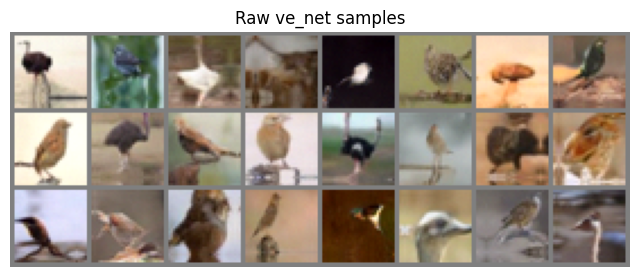

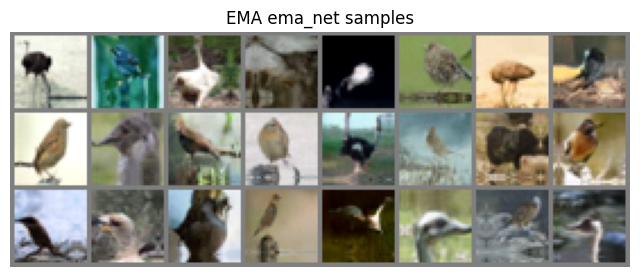

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/comparison_raw_ve_net_grid.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/comparison_ema_net_grid_ve.png

Running full evaluation for: ve_net1600_epochs


100%|██████████| 999/999 [00:49<00:00, 20.09it/s]


Generated 64/64 samples


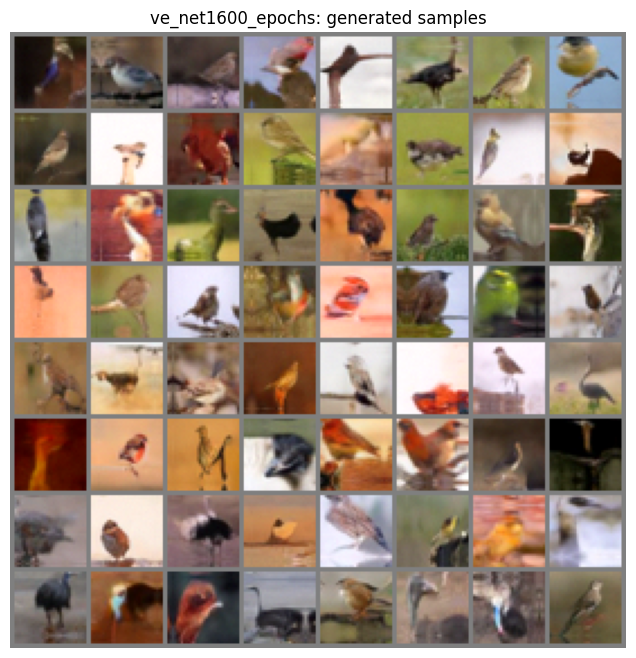

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/ve_net1600_epochs_generated_grid.png
Installing torchmetrics and torch-fidelity...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 36.0MB/s]


Real images added to FID: 1000


100%|██████████| 999/999 [00:49<00:00, 20.30it/s]


Generated images added to FID: 64/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:39<00:00, 25.30it/s]


Generated images added to FID: 1000/1000
FID: 68.47154998779297
Reference images: torch.Size([10, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [00:49<00:00, 20.33it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.1725742518901825
Median nearest-neighbor MSE: 0.14633587002754211
Minimum nearest-neighbor MSE: 0.06422428786754608
Maximum nearest-neighbor MSE: 0.40278148651123047


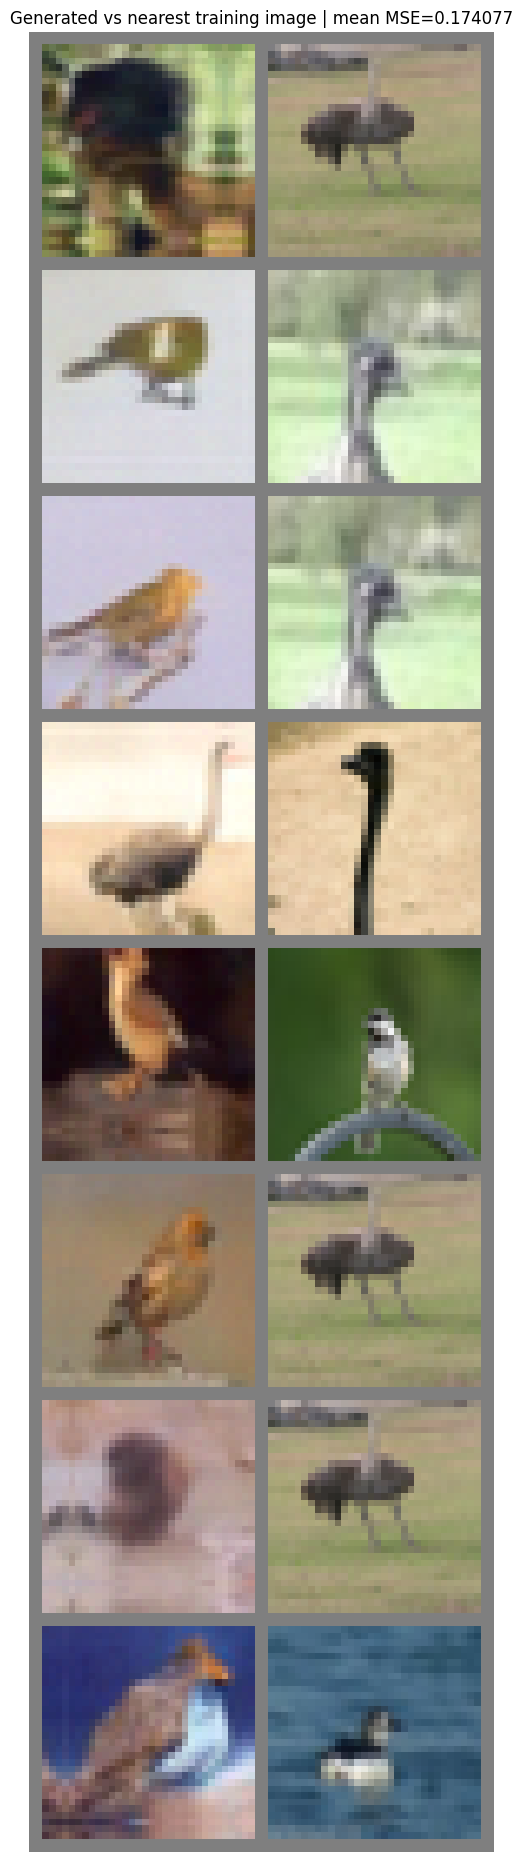

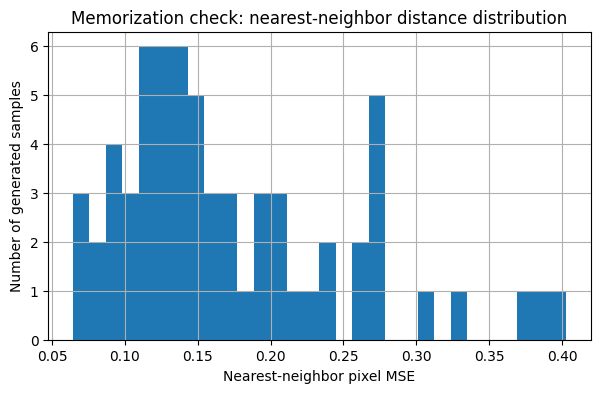

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/ve_net1600_epochs_evaluation_results.txt
{'model_name': 've_net1600_epochs', 'fid': 68.47154998779297, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.1725742518901825, 'mem_median_nn_mse': 0.14633587002754211, 'mem_min_nn_mse': 0.06422428786754608, 'mem_max_nn_mse': 0.40278148651123047}
Final VE_net evaluation results:
{'model_name': 've_net1600_epochs', 'fid': 68.47154998779297, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.1725742518901825, 'mem_median_nn_mse': 0.14633587002754211, 'mem_min_nn_mse': 0.06422428786754608, 'mem_max_nn_mse': 0.40278148651123047}

Running full evaluation for: EMA_net1600_epochs


100%|██████████| 999/999 [00:48<00:00, 20.50it/s]


Generated 64/64 samples


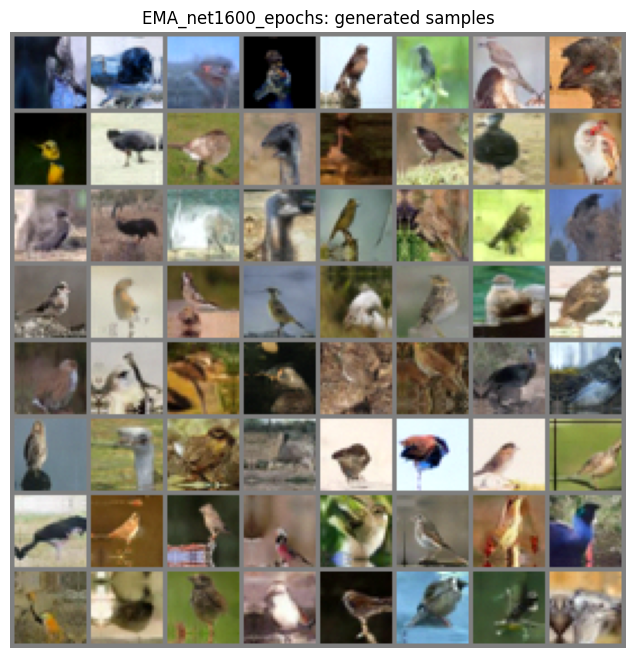

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/EMA_net1600_epochs_generated_grid.png
Real images added to FID: 1000


100%|██████████| 999/999 [00:48<00:00, 20.48it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:48<00:00, 20.43it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:39<00:00, 25.41it/s]


Generated images added to FID: 1000/1000
FID: 58.81342315673828
Reference images: torch.Size([10, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [00:49<00:00, 20.30it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.185520201921463
Median nearest-neighbor MSE: 0.15889538824558258
Minimum nearest-neighbor MSE: 0.07076721638441086
Maximum nearest-neighbor MSE: 0.4804861545562744


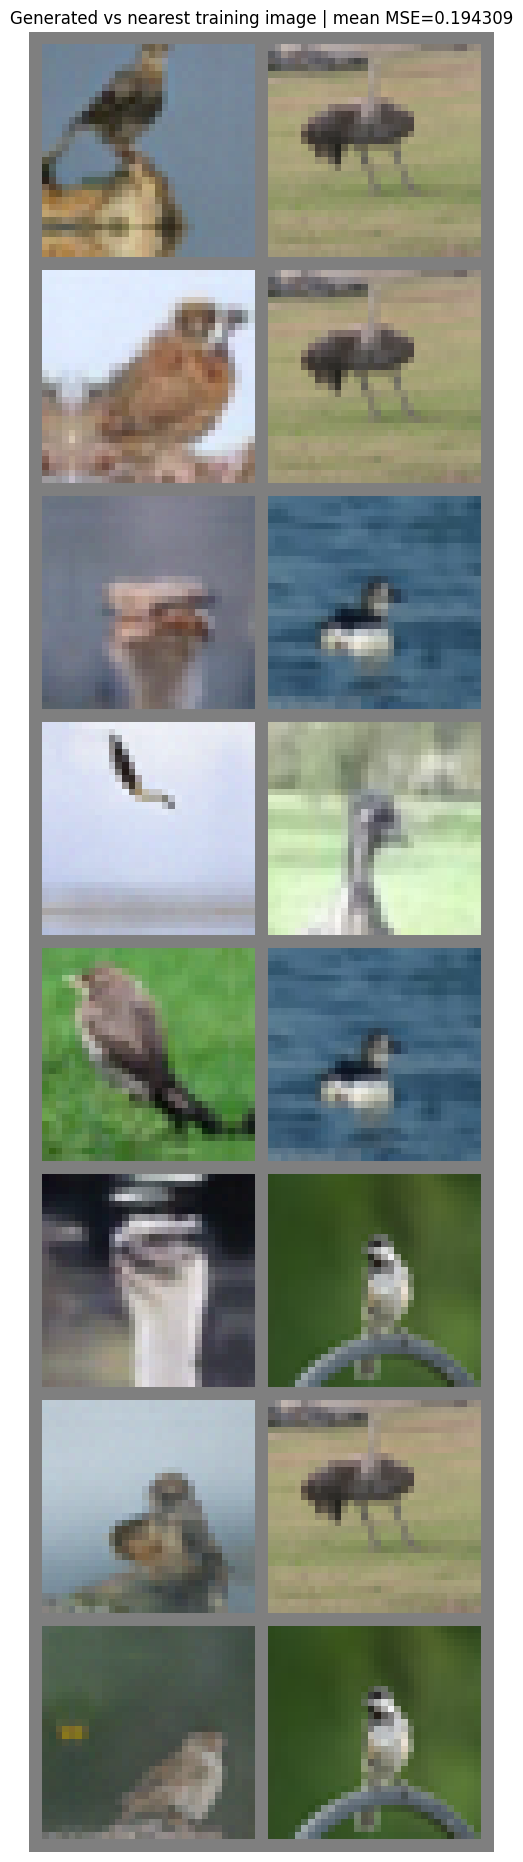

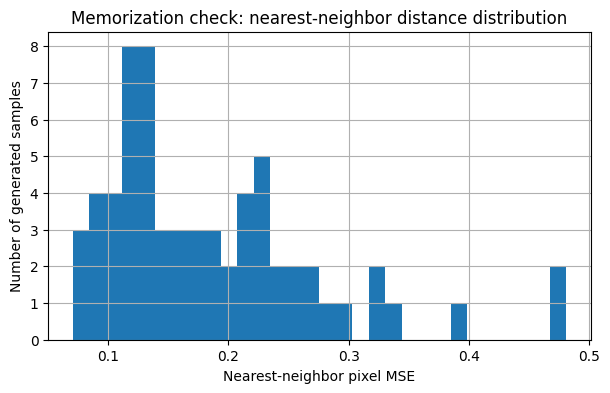

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/EMA_net1600_epochs_evaluation_results.txt
{'model_name': 'EMA_net1600_epochs', 'fid': 58.81342315673828, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.185520201921463, 'mem_median_nn_mse': 0.15889538824558258, 'mem_min_nn_mse': 0.07076721638441086, 'mem_max_nn_mse': 0.4804861545562744}
Final EMA-net evaluation results:
{'model_name': 'EMA_net1600_epochs', 'fid': 58.81342315673828, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.185520201921463, 'mem_median_nn_mse': 0.15889538824558258, 'mem_min_nn_mse': 0.07076721638441086, 'mem_max_nn_mse': 0.4804861545562744}


In [ ]:
if RUN_EVALUATION_AFTER_TRAINING:
    # Compare raw and EMA models visually
    samples_raw_compare, samples_ema_compare = compare_raw_vs_ema(ve_net=ve_net, ema_net=ema_net, num_samples=24, num_steps=sample_num_steps, corrector_steps=sample_corrector_steps)

    # Main full evaluation on VE model
    ve_net_results_ = run_full_evaluation(model=ve_net, model_name=f"ve_net{1600}_epochs",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final VE_net evaluation results:")
    print(ve_net_results_)
if RUN_EVALUATION_AFTER_TRAINING:

    # Main full evaluation on EMA model
    ve_net_results_ = run_full_evaluation(model=ema_net, model_name=f"EMA_net{1600}_epochs",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final EMA-net evaluation results:")
    print(ve_net_results_)



Running full evaluation for: EMA_net1600_epochs


100%|██████████| 999/999 [00:49<00:00, 20.36it/s]


Generated 64/64 samples


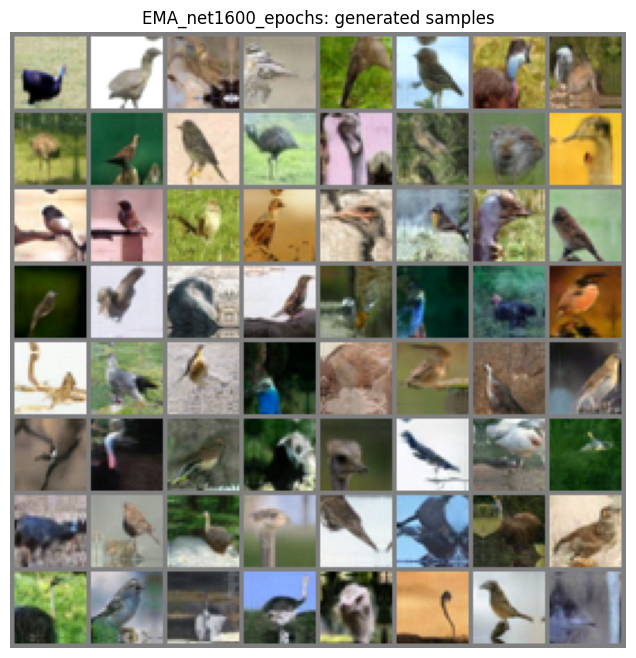

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/EMA_net1600_epochs_generated_grid.png
Real images added to FID: 1000


100%|██████████| 999/999 [00:48<00:00, 20.44it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:48<00:00, 20.40it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:39<00:00, 25.28it/s]


Generated images added to FID: 1000/1000
FID: 58.31614685058594
Reference images: torch.Size([10, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [00:48<00:00, 20.43it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.19776473939418793
Median nearest-neighbor MSE: 0.16959784924983978
Minimum nearest-neighbor MSE: 0.07272596657276154
Maximum nearest-neighbor MSE: 0.5222147107124329


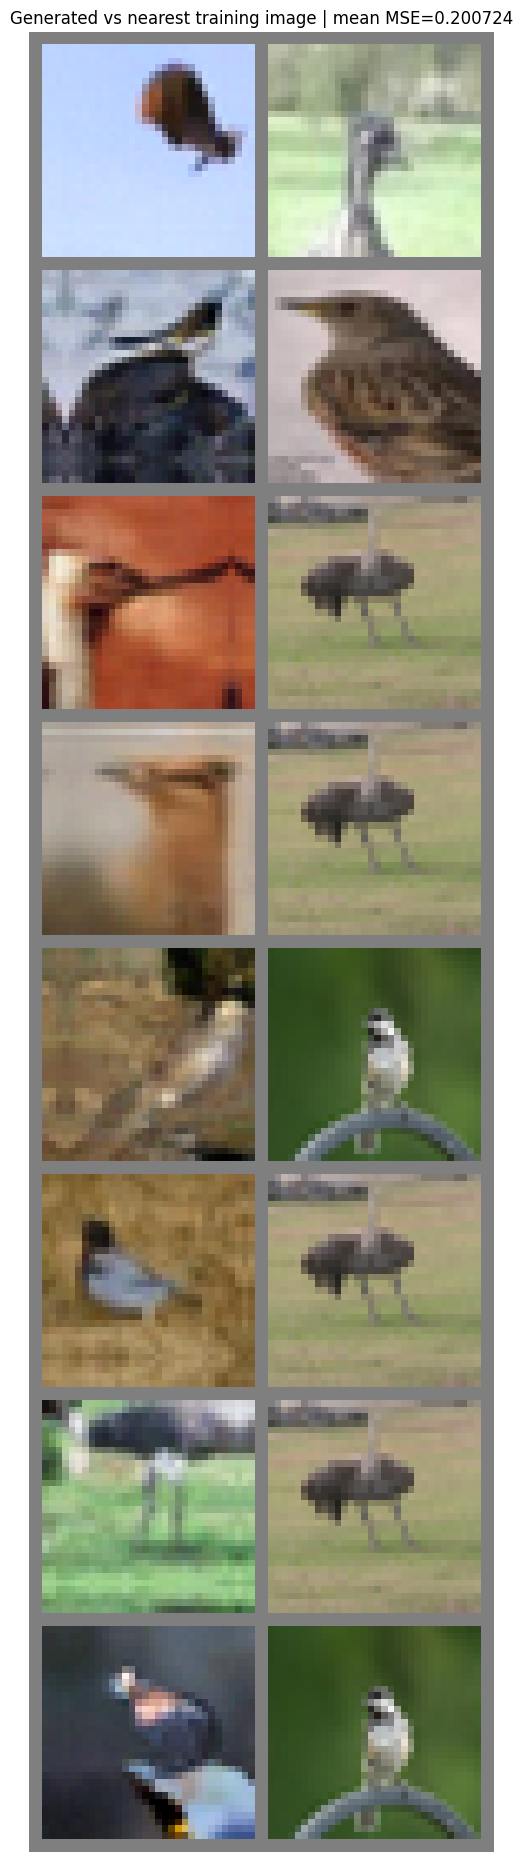

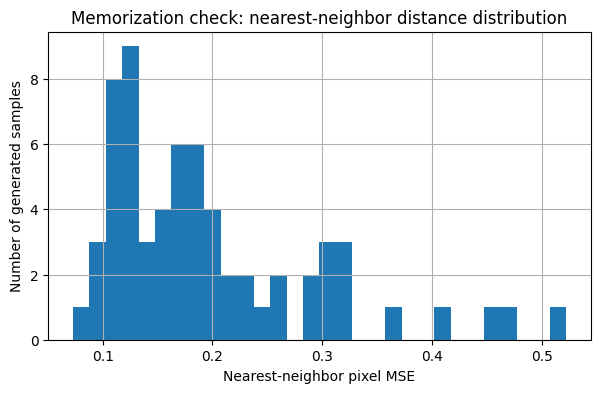

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/EMA_net1600_epochs_evaluation_results.txt
{'model_name': 'EMA_net1600_epochs', 'fid': 58.31614685058594, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.19776473939418793, 'mem_median_nn_mse': 0.16959784924983978, 'mem_min_nn_mse': 0.07272596657276154, 'mem_max_nn_mse': 0.5222147107124329}
Final EMA-net evaluation results:
{'model_name': 'EMA_net1600_epochs', 'fid': 58.31614685058594, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.19776473939418793, 'mem_median_nn_mse': 0.16959784924983978, 'mem_min_nn_mse': 0.07272596657276154, 'mem_max_nn_mse': 0.5222147107124329}


In [ ]:
if RUN_EVALUATION_AFTER_TRAINING:

    # Main full evaluation on EMA model
    ve_net_results_ = run_full_evaluation(model=ema_net, model_name=f"EMA_net{1600}_epochs",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final EMA-net evaluation results:")
    print(ve_net_results_) #oops


In [ ]:
eval_checkpoint_path = os.path.join(
    path,
    "/content/drive/MyDrive/DD2424/Project/bird_ve_augmented_ncsnpp_checkpoint_1760_epochs.pth" #bird_vp_sde_augmented_ddpmpp_1760_epochs
)

eval_epoch = 1760 #1760

# the same settings as before
eval_num_steps = 1000
eval_corrector_steps = 0

# FID/memorization sample counts
# Keep these fixed across augmented and non-augmented models for fair comparison.
eval_fid_num_generated = 1000
eval_mem_num_generated = 64

assert os.path.exists(eval_checkpoint_path), f"Checkpoint not found: {eval_checkpoint_path}"

print("Evaluation checkpoint:", eval_checkpoint_path)
print("FID generated samples:", eval_fid_num_generated)
print("Memorization generated samples:", eval_mem_num_generated)
print("Sampling steps:", eval_num_steps)


AssertionError: Checkpoint not found: /content/drive/MyDrive/DD2424/Project/bird_ve_augmented_ncsnpp_checkpoint_1760_epochs.pth